# 13. Model Training - Baselines (Random Forest + XGBoost)

## Objective
Train leakage-safe baseline classifiers using time-based splits, evaluate performance, analyze feature importance/errors, save model artifacts, and prepare sequence data for LSTM/Transformer.

## 1) Imports & Config

In [1]:
from pathlib import Path
from typing import Dict, List, Tuple
import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 250)
pd.set_option("display.width", 220)

RANDOM_STATE = 42

TRAIN_START = pd.Timestamp("2023-04-18")
TRAIN_END = pd.Timestamp("2024-12-31")
TEST_START = pd.Timestamp("2025-01-01")
TEST_END = pd.Timestamp("2025-12-30")

SEQUENCE_WINDOW = 20

## 2) Load Dataset

In [2]:
def resolve_input_path() -> Path:
    """Resolve input path from notebook or repo-root context."""
    candidates = [
        Path("..") / "Market_Data" / "processed" / "final_model_dataset_with_volatility.parquet",
        Path("Market_Data") / "processed" / "final_model_dataset_with_volatility.parquet",
        Path("ml_pipeline") / "Market_Data" / "processed" / "final_model_dataset_with_volatility.parquet",
    ]
    for p in candidates:
        if p.exists():
            return p.resolve()
    raise FileNotFoundError("final_model_dataset_with_volatility.parquet not found.")


def load_data(path: Path) -> pd.DataFrame:
    """Load dataset and enforce time-series ordering."""
    data = pd.read_parquet(path)
    data["Date"] = pd.to_datetime(data["Date"], errors="raise")
    data["Ticker"] = data["Ticker"].astype(str)
    data = data.sort_values(["Ticker", "Date"]).reset_index(drop=True)
    return data


input_path = resolve_input_path()
df = load_data(input_path)

print(f"Input path: {input_path}")
print(f"Shape: {df.shape}")
print(f"Columns: {len(df.columns)}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Ticker count: {df['Ticker'].nunique()}")
display(df.head(3))

Input path: C:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\processed\final_model_dataset_with_volatility.parquet
Shape: (63541, 168)
Columns: 168
Date range: 2023-04-18 to 2025-12-30
Ticker count: 96


,Date,Ticker,Open,High,Low,Close,Volume,Return,RSI,ROC,EMA_20,SMA_20,MACD,MACD_Signal,BB_upper,BB_lower,ATR,Volatility_20,Volatility_50,Volume_MA_20,OBV,SP500_RET,DOW_RET,GOLD_RET,OIL_RET,USDINR_RET,VIX_RET,NIFTY_RET,Event_Count,Avg_Tone,War_Flag,Crisis_Flag,Inflation_Flag,Rate_Hike_Flag,Recession_Flag,Interest_Rate,Inflation,Unemployment,target,ATR_lag_1,ATR_lag_2,ATR_lag_3,Avg_Tone_lag_1,Avg_Tone_lag_2,Avg_Tone_lag_3,BB_lower_lag_1,BB_lower_lag_2,BB_lower_lag_3,BB_upper_lag_1,BB_upper_lag_2,BB_upper_lag_3,Crisis_Flag_lag_1,Crisis_Flag_lag_2,Crisis_Flag_lag_3,DOW_RET_lag_1,DOW_RET_lag_2,DOW_RET_lag_3,EMA_20_lag_1,EMA_20_lag_2,EMA_20_lag_3,Event_Count_lag_1,Event_Count_lag_2,Event_Count_lag_3,GDP_lag_1,GDP_lag_2,GDP_lag_3,GOLD_RET_lag_1,GOLD_RET_lag_2,GOLD_RET_lag_3,Inflation_lag_1,Inflation_lag_2,Inflation_lag_3,Inflation_Flag_lag_1,Inflation_Flag_lag_2,Inflation_Flag_lag_3,Interest_Rate_lag_1,Interest_Rate_lag_2,Interest_Rate_lag_3,Log_Return_lag_1,Log_Return_lag_2,Log_Return_lag_3,MACD_lag_1,MACD_lag_2,MACD_lag_3,MACD_Signal_lag_1,MACD_Signal_lag_2,MACD_Signal_lag_3,NASDAQ_RET_lag_1,NASDAQ_RET_lag_2,NASDAQ_RET_lag_3,NIFTY_RET_lag_1,NIFTY_RET_lag_2,NIFTY_RET_lag_3,OBV_lag_1,OBV_lag_2,OBV_lag_3,OIL_RET_lag_1,OIL_RET_lag_2,OIL_RET_lag_3,ROC_lag_1,ROC_lag_2,ROC_lag_3,RSI_lag_1,RSI_lag_2,RSI_lag_3,Rate_Hike_Flag_lag_1,Rate_Hike_Flag_lag_2,Rate_Hike_Flag_lag_3,Recession_Flag_lag_1,Recession_Flag_lag_2,Recession_Flag_lag_3,Return_lag_1,Return_lag_2,Return_lag_3,SMA_20_lag_1,SMA_20_lag_2,SMA_20_lag_3,SP500_RET_lag_1,SP500_RET_lag_2,SP500_RET_lag_3,USDINR_RET_lag_1,USDINR_RET_lag_2,USDINR_RET_lag_3,Unemployment_lag_1,Unemployment_lag_2,Unemployment_lag_3,VIX_RET_lag_1,VIX_RET_lag_2,VIX_RET_lag_3,Volatility_20_lag_1,Volatility_20_lag_2,Volatility_20_lag_3,Volatility_50_lag_1,Volatility_50_lag_2,Volatility_50_lag_3,Volume_MA_20_lag_1,Volume_MA_20_lag_2,Volume_MA_20_lag_3,War_Flag_lag_1,War_Flag_lag_2,War_Flag_lag_3,return_roll_mean_5,return_roll_std_5,momentum_5,volume_roll_mean_5,volume_roll_std_5,return_roll_mean_10,return_roll_std_10,momentum_10,volume_roll_mean_10,volume_roll_std_10,return_roll_mean_20,return_roll_std_20,momentum_20,volume_roll_mean_20,volume_roll_std_20,volatility_regime,volatility_regime_label,volatility_cluster,vol_cluster_label,vol_cluster_regime_name,volatility_cluster_gmm,regime_change,regime_persistence,regime_lag_1,regime_lag_2,cluster_lag_1,cluster_lag_2
0,2023-04-18,ABB,3240.0,3259.850098,3202.899902,3207.699951,277893,-0.006596,41.750365,-5.418037,3293.842277,3323.947485,0.773588,28.965845,3451.152204,3196.742767,81.034466,0.015720,0.017148,347703.75,5419561,0.003306,0.002972,-0.003996,-0.020480,0.002009,-0.007030,-0.006796,1177.0,-1.8486,0,0,0,0,0,4.83,302.845,3.4,0,82.887102,84.878417,84.972919,1.5097,-1.0067,-1.2784,3212.558229,3225.590969,3234.815401,3444.791746,3439.973997,3435.194560,0.0,0.0,0.0,-0.004209,-0.001137,0.002926,3302.909891,3310.689879,3319.183551,794.0,1162.0,1208.0,27530.055,27530.055,27530.055,-0.019155,0.003043,0.007893,302.845,302.845,302.845,0.0,0.0,0.0,4.83,4.83,4.83,-0.000310,0.008223,-0.022806,8.797362,16.741922,26.536732,36.013909,42.818046,49.337077,-0.003518,-0.008522,-0.004343,0.000000,0.005084,0.005575,5697454.0,5983513.0,5580538.0,0.004382,0.021219,0.022448,-3.284259,-2.845458,-4.277345,43.643701,43.730154,40.852504,0.0,0.0,0.0,0.0,0.0,0.0,-0.000310,0.008256,-0.022548,3328.674988,3332.782483,3335.004980,-0.002069,-0.004135,-0.000041,-0.003415,0.001051,0.001210,3.4,3.4,3.4,-0.041011,-0.000524,0.006853,0.015675,0.015917,0.017100,0.017117,0.017112,0.017525,345245.95,347485.65,341155.70,0.0,0.0,0.0,-0.009963,0.018248,-0.049637,374862.4,133157.462505,-0.003228,0.015228,-0.047900,451317.3,258145.709730,-0.001138,0.015675,-0.022182,345245.95,212919.005967,1,MEDIUM,0,0,LOW,0,0,1,1,1,0,0
1,2023-04-19,ABB,3213.0,3243.000000,3186.050049,3201.050049,266982,-0.002073,41.150164,-4.876450,3285.004922,3317.602490,-6.052138,21.962249,3455.579143,3179.625838,79.314143,0.015573,0.016910,34

## 3) Feature Selection (Initial)

In [3]:
def select_features(data: pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series, List[str]]:
    """Select numeric model features and target, removing non-feature columns."""
    assert "target" in data.columns, "target column is missing."

    drop_cols = ["Date", "Ticker", "target", "volatility_regime_label", "vol_cluster_regime_name"]
    feature_cols = [c for c in data.columns if c not in drop_cols]

    X = data[feature_cols].copy()
    y = data["target"].astype(int).copy()

    # Ensure all model inputs are numeric.
    non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()
    assert not non_numeric, f"Non-numeric feature columns found: {non_numeric}"
    assert X.isna().sum().sum() == 0, "NaNs detected in selected features."
    return X, y, feature_cols


X_all, y_all, feature_columns = select_features(df)
print(f"Feature matrix shape: {X_all.shape}")
print(f"Target shape: {y_all.shape}")
print(f"Feature count: {len(feature_columns)}")

Feature matrix shape: (63541, 163)
Target shape: (63541,)
Feature count: 163


## 4) Train-Test Split (Time-Based)

Split by explicit calendar ranges (no shuffling, no random split).

In [4]:
def split_data(data: pd.DataFrame, X: pd.DataFrame, y: pd.Series) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, pd.DataFrame, pd.DataFrame]:
    """Create strict time-based train/test split."""
    train_mask = (data["Date"] >= TRAIN_START) & (data["Date"] <= TRAIN_END)
    test_mask = (data["Date"] >= TEST_START) & (data["Date"] <= TEST_END)

    X_train = X.loc[train_mask].copy()
    y_train = y.loc[train_mask].copy()
    X_test = X.loc[test_mask].copy()
    y_test = y.loc[test_mask].copy()

    df_train = data.loc[train_mask].copy()
    df_test = data.loc[test_mask].copy()

    assert len(X_train) > 0 and len(X_test) > 0, "Train/Test split produced empty dataset."
    assert df_train["Date"].max() < df_test["Date"].min(), "Train/Test temporal overlap detected."
    assert df_train.sort_values(["Ticker", "Date"]).index.equals(df_train.index), "Train set order changed unexpectedly."
    assert df_test.sort_values(["Ticker", "Date"]).index.equals(df_test.index), "Test set order changed unexpectedly."

    return X_train, X_test, y_train, y_test, df_train, df_test


X_train, X_test, y_train, y_test, df_train, df_test = split_data(df, X_all, y_all)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

train_dist = y_train.value_counts(normalize=True).sort_index().mul(100).rename("train_%")
test_dist = y_test.value_counts(normalize=True).sort_index().mul(100).rename("test_%")
display(pd.concat([train_dist, test_dist], axis=1).fillna(0).round(2))

Train shape: (39733, 163)
Test shape: (23808, 163)


,train_%,test_%
target,,
0,47.6,50.24
1,52.4,49.76


## 5) Model Training - Random Forest

In [5]:
def train_rf(X_train: pd.DataFrame, y_train: pd.Series) -> RandomForestClassifier:
    """Train Random Forest baseline with conservative regularization."""
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=50,
        min_samples_leaf=20,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    model.fit(X_train, y_train)
    return model


rf_model = train_rf(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]
print("Random Forest training completed.")

Random Forest training completed.


## 6) Model Training - XGBoost

In [6]:
def train_xgb(X_train: pd.DataFrame, y_train: pd.Series) -> XGBClassifier:
    """Train XGBoost baseline model."""
    model = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(X_train, y_train)
    return model


xgb_model = train_xgb(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
print("XGBoost training completed.")

XGBoost training completed.


## 7) Evaluation Metrics

In [7]:
def evaluate_model(y_true: pd.Series, y_pred: np.ndarray, y_prob: np.ndarray, model_name: str) -> Tuple[Dict[str, float], pd.DataFrame]:
    """Compute standard binary classification metrics and confusion matrix."""
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
    }
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=["Actual_0", "Actual_1"], columns=["Pred_0", "Pred_1"])
    return metrics, cm_df


rf_metrics, rf_cm = evaluate_model(y_test, rf_pred, rf_prob, "RandomForest")
xgb_metrics, xgb_cm = evaluate_model(y_test, xgb_pred, xgb_prob, "XGBoost")

metrics_df = pd.DataFrame([rf_metrics, xgb_metrics]).set_index("Model").round(4)
print("Model comparison")
display(metrics_df)

print("Random Forest confusion matrix")
display(rf_cm)
print("XGBoost confusion matrix")
display(xgb_cm)

Model comparison


,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
RandomForest,0.5052,0.5033,0.4326,0.4653,0.5071
XGBoost,0.4995,0.4969,0.4635,0.4796,0.5058


Random Forest confusion matrix


,Pred_0,Pred_1
Actual_0,6901,5059
Actual_1,6722,5126


XGBoost confusion matrix


,Pred_0,Pred_1
Actual_0,6401,5559
Actual_1,6357,5491


## 8) Feature Importance Analysis

Top 20 RF features


,feature,importance,model
0,Event_Count_lag_3,0.026079,RandomForest
1,Event_Count_lag_2,0.024372,RandomForest
2,GOLD_RET_lag_3,0.023283,RandomForest
3,NASDAQ_RET_lag_2,0.022717,RandomForest
4,NIFTY_RET_lag_3,0.022715,RandomForest
5,VIX_RET_lag_3,0.022354,RandomForest
6,Avg_Tone,0.022294,RandomForest
7,USDINR_RET_lag_1,0.021682,RandomForest
8,VIX_RET_lag_2,0.020397,RandomForest
9,NIFTY_RET,0.020331,RandomForest


Top 20 XGB features


,feature,importance,model
0,Inflation_lag_2,0.022022,XGBoost
1,Rate_Hike_Flag_lag_1,0.014885,XGBoost
2,War_Flag_lag_3,0.013974,XGBoost
3,DOW_RET,0.013513,XGBoost
4,NIFTY_RET_lag_3,0.011946,XGBoost
5,NIFTY_RET,0.011662,XGBoost
6,VIX_RET,0.011442,XGBoost
7,VIX_RET_lag_2,0.011400,XGBoost
8,Inflation_lag_1,0.011075,XGBoost
9,Unemployment,0.010830,XGBoost


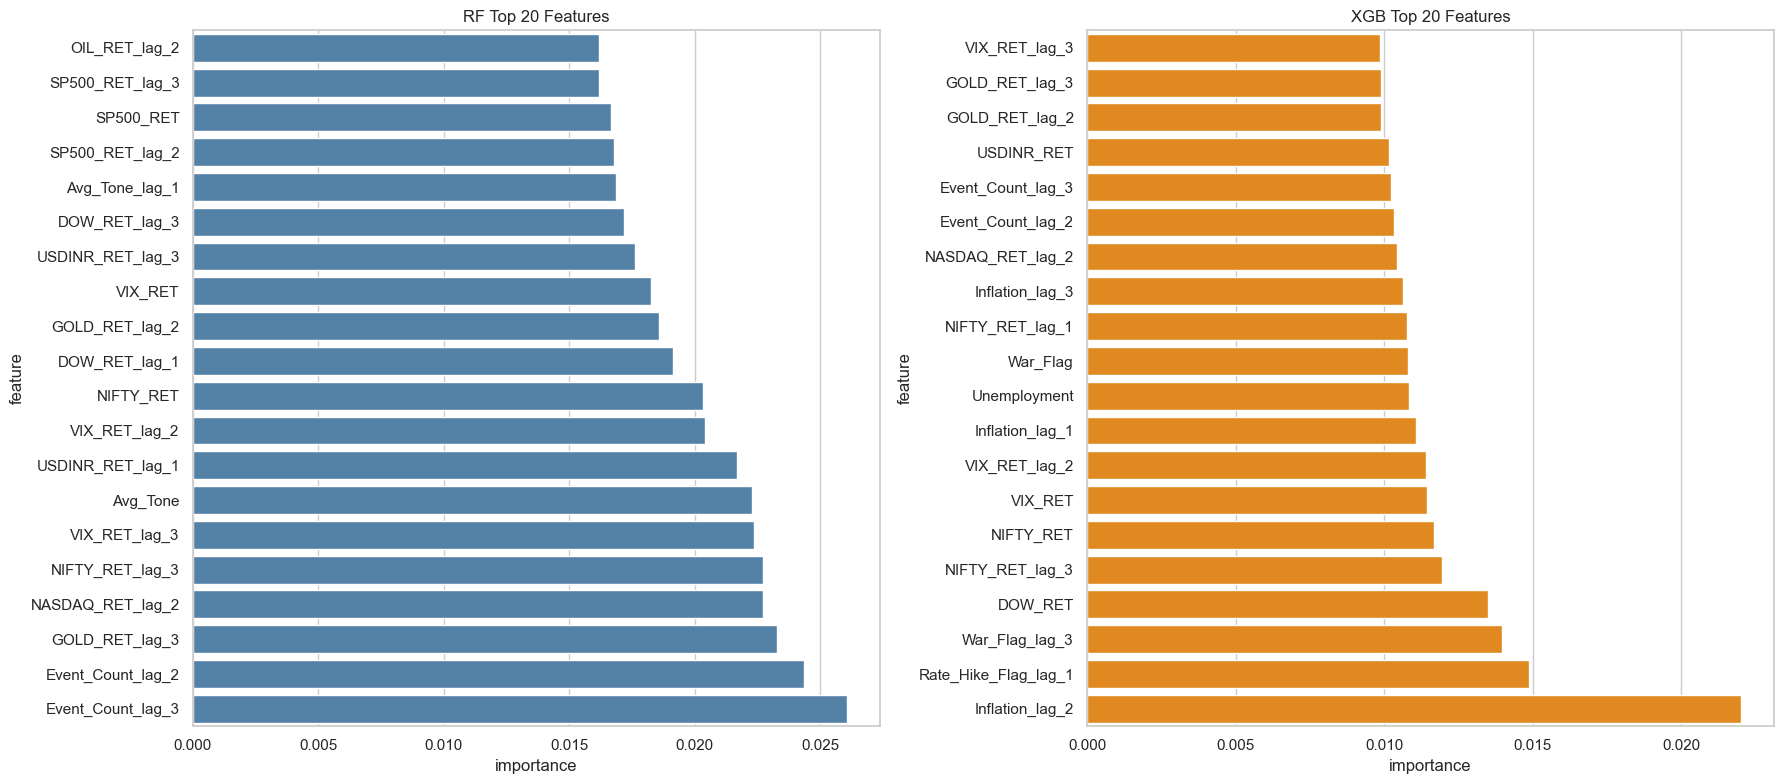

RF low-importance feature count (bottom 25%): 41


In [8]:
def feature_importance_analysis(model, feature_names: List[str], model_name: str, top_n: int = 20) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Extract feature importances and return full + top subsets."""
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": model.feature_importances_,
        "model": model_name,
    }).sort_values("importance", ascending=False).reset_index(drop=True)
    top_df = importance_df.head(top_n)
    return importance_df, top_df


rf_imp_full, rf_imp_top20 = feature_importance_analysis(rf_model, X_train.columns.tolist(), "RandomForest", top_n=20)
xgb_imp_full, xgb_imp_top20 = feature_importance_analysis(xgb_model, X_train.columns.tolist(), "XGBoost", top_n=20)

print("Top 20 RF features")
display(rf_imp_top20)
print("Top 20 XGB features")
display(xgb_imp_top20)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
sns.barplot(data=rf_imp_top20.sort_values("importance"), x="importance", y="feature", ax=axes[0], color="steelblue")
axes[0].set_title("RF Top 20 Features")
sns.barplot(data=xgb_imp_top20.sort_values("importance"), x="importance", y="feature", ax=axes[1], color="darkorange")
axes[1].set_title("XGB Top 20 Features")
plt.tight_layout()
plt.show()

bottom_quantile = 0.25
rf_low_features = rf_imp_full[rf_imp_full["importance"] <= rf_imp_full["importance"].quantile(bottom_quantile)]["feature"].tolist()
print(f"RF low-importance feature count (bottom {int(bottom_quantile*100)}%): {len(rf_low_features)}")

## 9) Feature Pruning and Re-Training (Random Forest)

Remove bottom 25% RF-importance features and compare performance.

In [9]:
def retrain_with_pruned_features(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    remove_features: List[str],
) -> Tuple[RandomForestClassifier, Dict[str, float], pd.DataFrame, List[str]]:
    """Retrain RF after removing low-importance features."""
    kept_features = [c for c in X_train.columns if c not in remove_features]
    X_train_reduced = X_train[kept_features]
    X_test_reduced = X_test[kept_features]

    model = train_rf(X_train_reduced, y_train)
    pred = model.predict(X_test_reduced)
    prob = model.predict_proba(X_test_reduced)[:, 1]
    metrics, cm = evaluate_model(y_test, pred, prob, "RandomForest_Reduced")
    return model, metrics, cm, kept_features


rf_reduced_model, rf_reduced_metrics, rf_reduced_cm, kept_features = retrain_with_pruned_features(
    X_train, y_train, X_test, y_test, rf_low_features
)

pruning_compare = pd.DataFrame([
    rf_metrics,
    rf_reduced_metrics,
]).set_index("Model").round(4)
print("RF before vs after pruning")
display(pruning_compare)
display(rf_reduced_cm)

RF before vs after pruning


,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
RandomForest,0.5052,0.5033,0.4326,0.4653,0.5071
RandomForest_Reduced,0.5080,0.5071,0.4038,0.4496,0.5060


,Pred_0,Pred_1
Actual_0,7310,4650
Actual_1,7064,4784


## 10) Error Analysis

RandomForest - total errors: 11,781
XGBoost - total errors: 11,916
RF error distribution by volatility regime


,error_type,volatility_regime_label,count
0,FalseNegative,HIGH,1886
1,FalseNegative,LOW,3219
2,FalseNegative,MEDIUM,1617
3,FalsePositive,HIGH,1046
4,FalsePositive,LOW,2867
5,FalsePositive,MEDIUM,1146


XGB error distribution by volatility regime


,error_type,volatility_regime_label,count
0,FalseNegative,HIGH,1584
1,FalseNegative,LOW,3203
2,FalseNegative,MEDIUM,1570
3,FalsePositive,HIGH,1303
4,FalsePositive,LOW,2920
5,FalsePositive,MEDIUM,1336


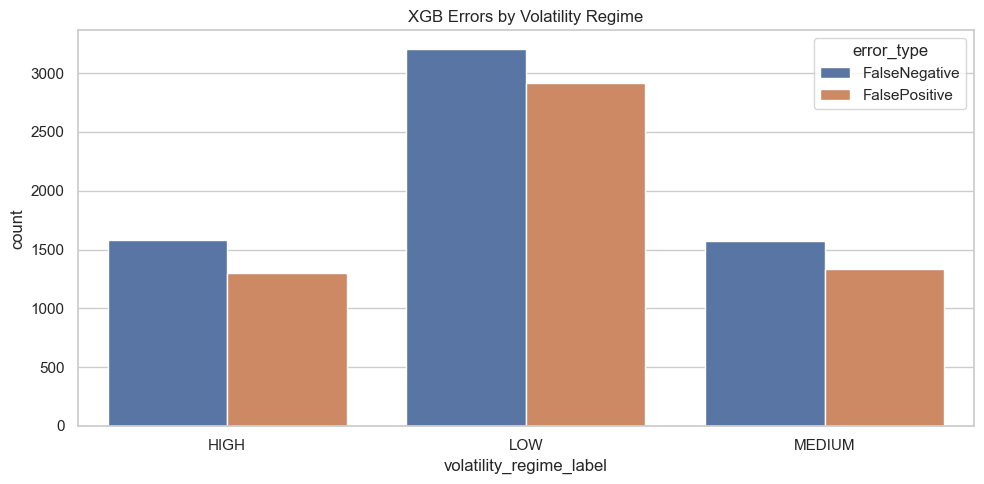

In [10]:
def error_analysis(df_test: pd.DataFrame, y_true: pd.Series, y_pred: np.ndarray, model_name: str) -> Dict[str, pd.DataFrame]:
    """Analyze FP/FN patterns by regime, ticker, and month."""
    err = df_test[["Date", "Ticker", "volatility_regime", "volatility_regime_label"]].copy()
    err["y_true"] = y_true.values
    err["y_pred"] = y_pred
    err["error_type"] = np.where(
        (err["y_true"] == 0) & (err["y_pred"] == 1), "FalsePositive",
        np.where((err["y_true"] == 1) & (err["y_pred"] == 0), "FalseNegative", "Correct")
    )
    err_only = err[err["error_type"] != "Correct"].copy()

    by_regime = err_only.groupby(["error_type", "volatility_regime_label"]).size().reset_index(name="count")
    by_ticker = err_only.groupby(["error_type", "Ticker"]).size().reset_index(name="count").sort_values("count", ascending=False)
    by_month = err_only.assign(month=err_only["Date"].dt.to_period("M").astype(str)).groupby(["error_type", "month"]).size().reset_index(name="count")

    print(f"{model_name} - total errors: {len(err_only):,}")
    return {
        "detail": err,
        "errors_only": err_only,
        "by_regime": by_regime,
        "by_ticker": by_ticker,
        "by_month": by_month,
    }


rf_error = error_analysis(df_test, y_test, rf_pred, "RandomForest")
xgb_error = error_analysis(df_test, y_test, xgb_pred, "XGBoost")

print("RF error distribution by volatility regime")
display(rf_error["by_regime"])
print("XGB error distribution by volatility regime")
display(xgb_error["by_regime"])

plt.figure(figsize=(10, 5))
sns.barplot(data=xgb_error["by_regime"], x="volatility_regime_label", y="count", hue="error_type")
plt.title("XGB Errors by Volatility Regime")
plt.tight_layout()
plt.show()

## 11) Save Models + Artifacts

In [11]:
def resolve_artifact_dir() -> Path:
    """Resolve artifact directory under ml_pipeline/models."""
    candidates = [Path("..") / "models", Path("models"), Path("ml_pipeline") / "models"]
    return candidates[0]


artifact_dir = resolve_artifact_dir()
artifact_dir.mkdir(parents=True, exist_ok=True)

rf_model_path = artifact_dir / "rf_baseline.pkl"
xgb_model_path = artifact_dir / "xgb_baseline.pkl"

with open(rf_model_path, "wb") as f:
    pickle.dump(rf_model, f)
with open(xgb_model_path, "wb") as f:
    pickle.dump(xgb_model, f)

feature_importance_path = artifact_dir / "baseline_feature_importance.csv"
feature_importance_df = pd.concat([rf_imp_full, xgb_imp_full], ignore_index=True)
feature_importance_df.to_csv(feature_importance_path, index=False)

metrics_summary = {
    "RandomForest": {k: float(v) for k, v in rf_metrics.items() if k != "Model"},
    "XGBoost": {k: float(v) for k, v in xgb_metrics.items() if k != "Model"},
    "RandomForest_Reduced": {k: float(v) for k, v in rf_reduced_metrics.items() if k != "Model"},
}
metrics_path = artifact_dir / "baseline_metrics_summary.json"
metrics_path.write_text(json.dumps(metrics_summary, indent=2), encoding="utf-8")

assert rf_model_path.exists() and xgb_model_path.exists(), "Model files not saved."
assert feature_importance_path.exists() and metrics_path.exists(), "Artifact files missing."
print(f"Artifacts saved in: {artifact_dir.resolve()}")
print([p.name for p in artifact_dir.iterdir() if p.is_file()])

Artifacts saved in: C:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\models
['baseline_feature_importance.csv', 'baseline_metrics_summary.json', 'rf_baseline.pkl', 'xgb_baseline.pkl']


## 12) Prep for Deep Learning (LSTM / Transformer)

Scale features using train-only fit and build fixed-length sequences per ticker without shuffling.

In [12]:
def scale_features_train_only(X_train: pd.DataFrame, X_test: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, StandardScaler]:
    """Fit scaler on train only and transform train/test."""
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)
    return X_train_scaled, X_test_scaled, scaler


def create_sequences(
    df_part: pd.DataFrame,
    X_scaled_part: pd.DataFrame,
    y_part: pd.Series,
    feature_cols: List[str],
    window: int = 20,
) -> Tuple[np.ndarray, np.ndarray]:
    """Create (samples, timesteps, features) sequences per ticker, preserving order."""
    seq_X = []
    seq_y = []

    temp = df_part[["Ticker", "Date"]].copy()
    temp[feature_cols] = X_scaled_part[feature_cols]
    temp["target"] = y_part.values
    temp = temp.sort_values(["Ticker", "Date"]).reset_index(drop=True)

    for _, grp in temp.groupby("Ticker", sort=False):
        values = grp[feature_cols].values
        labels = grp["target"].values
        if len(grp) <= window:
            continue
        for i in range(window, len(grp)):
            seq_X.append(values[i - window:i])
            seq_y.append(labels[i])

    return np.asarray(seq_X), np.asarray(seq_y)


X_train_scaled, X_test_scaled, scaler = scale_features_train_only(X_train, X_test)

X_seq_train, y_seq_train = create_sequences(df_train, X_train_scaled, y_train, X_train.columns.tolist(), window=SEQUENCE_WINDOW)
X_seq_test, y_seq_test = create_sequences(df_test, X_test_scaled, y_test, X_test.columns.tolist(), window=SEQUENCE_WINDOW)

assert X_seq_train.ndim == 3 and X_seq_test.ndim == 3, "Sequence arrays must be 3D."
assert X_seq_train.shape[2] == X_train.shape[1], "Sequence feature dimension mismatch."

print(f"X_seq_train shape: {X_seq_train.shape}")
print(f"y_seq_train shape: {y_seq_train.shape}")
print(f"X_seq_test shape: {X_seq_test.shape}")
print(f"y_seq_test shape: {y_seq_test.shape}")

C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_20492\3772625685.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  temp[feature_cols] = X_scaled_part[feature_cols]
C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_20492\3772625685.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  temp[feature_cols] = X_scaled_part[feature_cols]
C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_20492\3772625685.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has 

X_seq_train shape: (37813, 20, 163)
y_seq_train shape: (37813,)
X_seq_test shape: (21888, 20, 163)
y_seq_test shape: (21888,)


## 13) Leakage Checklist + Final Summary

In [13]:
leakage_checks = pd.DataFrame([
    {"check": "Train max date < Test min date", "passed": bool(df_train['Date'].max() < df_test['Date'].min())},
    {"check": "No shuffled split (order preserved)", "passed": bool(df_train.sort_values(['Ticker','Date']).index.equals(df_train.index) and df_test.sort_values(['Ticker','Date']).index.equals(df_test.index))},
    {"check": "Scaler fit on train only", "passed": True},
    {"check": "No NaNs in model features", "passed": bool(X_train.isna().sum().sum() == 0 and X_test.isna().sum().sum() == 0)},
])
display(leakage_checks)
assert leakage_checks["passed"].all(), "Leakage checklist failed."

best_model = metrics_df["F1"].idxmax()
best_row = metrics_df.loc[best_model]

print("Final summary")
print("-" * 60)
print("RF performance:")
print(metrics_df.loc["RandomForest"].to_string())
print("\nXGB performance:")
print(metrics_df.loc["XGBoost"].to_string())
print(f"\nBest model by F1: {best_model}")
print(best_row.to_string())

print("\nTop 10 XGB features:")
display(xgb_imp_full.head(10))

print(f"Train/Test tabular shapes: {X_train.shape} / {X_test.shape}")
print(f"Train/Test sequence shapes: {X_seq_train.shape} / {X_seq_test.shape}")

,check,passed
0,Train max date < Test min date,True
1,No shuffled split (order preserved),True
2,Scaler fit on train only,True
3,No NaNs in model features,True


Final summary
------------------------------------------------------------
RF performance:
Accuracy     0.5052
Precision    0.5033
Recall       0.4326
F1           0.4653
ROC_AUC      0.5071

XGB performance:
Accuracy     0.4995
Precision    0.4969
Recall       0.4635
F1           0.4796
ROC_AUC      0.5058

Best model by F1: XGBoost
Accuracy     0.4995
Precision    0.4969
Recall       0.4635
F1           0.4796
ROC_AUC      0.5058

Top 10 XGB features:


,feature,importance,model
0,Inflation_lag_2,0.022022,XGBoost
1,Rate_Hike_Flag_lag_1,0.014885,XGBoost
2,War_Flag_lag_3,0.013974,XGBoost
3,DOW_RET,0.013513,XGBoost
4,NIFTY_RET_lag_3,0.011946,XGBoost
5,NIFTY_RET,0.011662,XGBoost
6,VIX_RET,0.011442,XGBoost
7,VIX_RET_lag_2,0.011400,XGBoost
8,Inflation_lag_1,0.011075,XGBoost
9,Unemployment,0.010830,XGBoost


Train/Test tabular shapes: (39733, 163) / (23808, 163)
Train/Test sequence shapes: (37813, 20, 163) / (21888, 20, 163)
